In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
import shap
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel

In [15]:
df = pd.read_csv('nt_crime_processed.csv')
print(df.columns)
#Inspection

Index(['Unnamed: 0', 'region', 'Year', 'Month number', 'Alcohol involvement',
       'DV involvement', 'Total_population', 'Aboriginal', 'Non-Aboriginal',
       'Male', 'Female', 'Pop_age_0', 'Pop_age_10', 'Pop_age_15', 'Pop_age_20',
       'Pop_age_25', 'Pop_age_30', 'Pop_age_35', 'Pop_age_40', 'Pop_age_45',
       'Pop_age_5', 'Pop_age_50', 'Pop_age_55', 'Pop_age_60', 'Pop_age_65',
       'Pop_age_70', 'Pop_age_75', 'Pop_age_80', 'Pop_age_85plus',
       'Cask Wine PAC', 'Bottled Wine PAC', 'Fortified Wine PAC', 'Cider PAC',
       'Standard Spirits PAC', 'Mixed Spirits PAC', 'Full-Strength Beer PAC',
       'Mid-Strength Beer PAC', 'Low-Strength Beer PAC', 'Total PAC',
       'Number of offences', 'assault_rate', 'sin_month', 'cos_month',
       'pct_aboriginal', 'pct_male', 'pct_youth', 'pct_senior',
       'alcohol_per_capita', 'full-strength_beer_pac_per_capita',
       'mid-strength_beer_pac_per_capita', 'low-strength_beer_pac_per_capita',
       'cask_wine_pac_per_capita', 'bo

Reasearch question 3: Classifcation of regions and month in risk class


=== TIME SERIES CV RESULTS (ALL DATA: 2024 + 2025) ===
 fold  train_size  val_size  GNB_accuracy  RF_accuracy
    1          30        30      0.800000     0.800000
    2          60        30      0.666667     0.800000
    3          90        30      0.733333     0.833333

GNB mean accuracy: 0.7333
RF mean accuracy: 0.8111
GNB std accuracy: 0.0544
RF std accuracy: 0.0157

=== Paired t-test: Gaussian Naive Bayes vs Random Forest ===
t-statistic: -1.9415
p-value: 0.1917
60

=== RANDOM FOREST HYPERPARAMETER OPTIMIZATION ===
Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best cross-validation score: 0.8444

=== GAUSSIAN NAIVE BAYES (2024 TRAIN → 2025 TEST) ===
[[15  0  1]
 [ 1 12  3]
 [11  3 14]]
              precision    recall  f1-score   support

        high       0.56      0.94      0.70        16
         low       0.80      0.75      0.

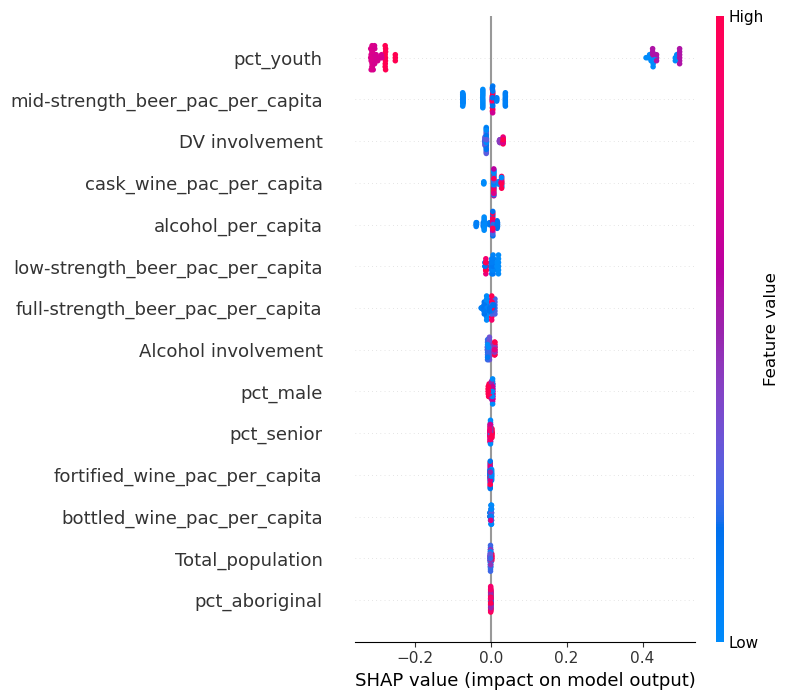

In [29]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.svm import SVC
import shap
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD DATA (region × month)
# ---------------------------------------------------------
df = pd.read_csv("nt_crime_processed.csv")

# ---------------------------------------------------------
# 2. SELECT FEATURES FOR MONTH-LEVEL CLASSIFICATION
# ---------------------------------------------------------
feature_cols = [
    'Total_population',
    'Alcohol involvement',
    'DV involvement',
    'pct_aboriginal',
    'pct_male',
    'pct_youth',
    'pct_senior',
    'alcohol_per_capita',
    'full-strength_beer_pac_per_capita',
    'mid-strength_beer_pac_per_capita',
    'low-strength_beer_pac_per_capita',
    'cask_wine_pac_per_capita',
    'bottled_wine_pac_per_capita',
    'fortified_wine_pac_per_capita'
]

cols_to_keep = ['region', 'Year', 'Month number', 'assault_rate'] + feature_cols
df = df[cols_to_keep]

# ---------------------------------------------------------
# 3. CREATE MONTH-LEVEL RISK CLASS (NO LEAKAGE)
# ---------------------------------------------------------

# Fit quantile edges ONLY on 2024 monthly data
train_2024 = df[df["Year"] == 2024]
quantile_edges = train_2024["assault_rate"].quantile([0, 0.33, 0.66, 1]).values

# Apply fixed bins to ALL months using 2024 quantiles
df["risk_class"] = pd.cut(
    df["assault_rate"],
    bins=quantile_edges,
    labels=["low", "medium", "high"],
    include_lowest=True
)

# For out-of-distribution values, assign to boundary classes (no leakage)
# Values below 2024 min → "low"; values above 2024 max → "high"
df.loc[df["risk_class"].isna() & (df["assault_rate"] < quantile_edges[0]), "risk_class"] = "low"
df.loc[df["risk_class"].isna() & (df["assault_rate"] > quantile_edges[-1]), "risk_class"] = "high"

df["risk_class"] = df["risk_class"].astype(str)

# Sort by Year and Month to ensure temporal order
df = df.sort_values(['Year', 'Month number']).reset_index(drop=True)

# ---------------------------------------------------------
# 4. PREPARE ALL DATA FOR TIME SERIES CV
# ---------------------------------------------------------
X_all = df[feature_cols]
y_all = df['risk_class']

# ---------------------------------------------------------
# 4A. TIME SERIES CROSS-VALIDATION (ALL DATA: 2024 + 2025)
# ---------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=3)

gnb_cv_scores = []
rf_cv_scores = []
fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all)):
    X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]

    # Gaussian Naive Bayes pipeline
    gnb_cv = Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ])
    gnb_cv.fit(X_tr, y_tr)
    gnb_pred = gnb_cv.predict(X_val)
    gnb_acc = accuracy_score(y_val, gnb_pred)
    gnb_cv_scores.append(gnb_acc)

    # Random Forest
    rf_cv = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42
    )
    rf_cv.fit(X_tr, y_tr)
    rf_pred = rf_cv.predict(X_val)
    rf_acc = accuracy_score(y_val, rf_pred)
    rf_cv_scores.append(rf_acc)
    
    fold_results.append({
        'fold': fold + 1,
        'train_size': len(X_tr),
        'val_size': len(X_val),
        'GNB_accuracy': gnb_acc,
        'RF_accuracy': rf_acc
    })

print("\n=== TIME SERIES CV RESULTS (ALL DATA: 2024 + 2025) ===")
fold_df = pd.DataFrame(fold_results)
print(fold_df.to_string(index=False))
print(f"\nGNB mean accuracy: {np.mean(gnb_cv_scores):.4f}")
print(f"RF mean accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"GNB std accuracy: {np.std(gnb_cv_scores):.4f}")
print(f"RF std accuracy: {np.std(rf_cv_scores):.4f}")

# Paired t-test
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(gnb_cv_scores, rf_cv_scores)
print("\n=== Paired t-test: Gaussian Naive Bayes vs Random Forest ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

# ---------------------------------------------------------
# 5. TRAIN ON 2024 MONTHS, TEST ON 2025 MONTHS (FINAL MODELS)
# ---------------------------------------------------------
train = df[df['Year'] == 2024]
test  = df[df['Year'] == 2025]

print(len(test))

X_train = train[feature_cols]
y_train = train['risk_class']

X_test = test[feature_cols]
y_test = test['risk_class']

# ---------------------------------------------------------
# 5A. RANDOM FOREST HYPERPARAMETER OPTIMIZATION
# ---------------------------------------------------------
print("\n=== RANDOM FOREST HYPERPARAMETER OPTIMIZATION ===")

# Define parameter grid
rf_param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Create base Random Forest model
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Use TimeSeriesSplit for cross-validation to respect temporal order
tscv_cv = TimeSeriesSplit(n_splits=3)

# Perform grid search
rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=tscv_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
rf_grid_search.fit(X_train, y_train)

# Get best parameters and score
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best cross-validation score: {rf_grid_search.best_score_:.4f}")

# Use best model for final evaluation
rf_best = rf_grid_search.best_estimator_

# ---------------------------------------------------------
# 6. GAUSSIAN NAIVE BAYES
# ---------------------------------------------------------
gnb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])

gnb_pipe.fit(X_train, y_train)
y_pred_gnb = gnb_pipe.predict(X_test)

print("\n=== GAUSSIAN NAIVE BAYES (2024 TRAIN → 2025 TEST) ===")
print(confusion_matrix(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))

# ---------------------------------------------------------
# 7. SUPPORT VECTOR MACHINE HYPERPARAMETER OPTIMIZATION
# ---------------------------------------------------------
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(class_weight='balanced', random_state=42))
])

svm_param_grid = {
    'model__kernel': ['rbf', 'poly'],
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto']
}

svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=tscv_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print("\n=== SUPPORT VECTOR MACHINE HYPERPARAMETER OPTIMIZATION ===")
print(f"Best parameters: {svm_grid_search.best_params_}")
print(f"Best cross-validation score: {svm_grid_search.best_score_:.4f}")

svm_best = svm_grid_search.best_estimator_

# ---------------------------------------------------------
# 8. SUPPORT VECTOR MACHINE (FINAL)
# ---------------------------------------------------------
y_pred_svm = svm_best.predict(X_test)

print("\n=== SUPPORT VECTOR MACHINE (2025) ===")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# ---------------------------------------------------------
# 9. RANDOM FOREST CLASSIFIER (OPTIMIZED)
# ---------------------------------------------------------
# Use the optimized Random Forest model from grid search
rf = rf_best

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== RANDOM FOREST (OPTIMIZED, 2024 TRAIN → 2025 TEST) ===")
print(f"Best parameters used: {rf_grid_search.best_params_}")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ---------------------------------------------------------
# 8. RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRANDOM FOREST FEATURE IMPORTANCE")
print(rf_importance)

# ---------------------------------------------------------
# 9. SHAP EXPLANATION
# ---------------------------------------------------------

# Convert to numpy to avoid SHAP/pandas column-order bug
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_np)


# Identify correct index for "high" class

high_idx = list(rf.classes_).index("high")

# Handle both old SHAP (list) and new SHAP (3D ndarray)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals_high = shap_values[:, :, high_idx]
else:
    shap_vals_high = shap_values[high_idx]

# SHAP summary plot
shap.summary_plot(
    shap_vals_high,
    X_test_np,
    feature_names=feature_cols
)


In [17]:
# GaussianNB model summary
# Note: GaussianNB from sklearn doesn't provide summary statistics like statsmodels
# but we can calculate accuracy and feature distribution statistics

# Already fit: gnb_pipe

# Get training and test accuracy
gnb_train_acc = gnb_pipe.score(X_train, y_train)
gnb_test_acc = gnb_pipe.score(X_test, y_test)

print("\n=== GAUSSIAN NAIVE BAYES MODEL PERFORMANCE ===")
print(f"Training Accuracy: {gnb_train_acc:.4f}")
print(f"Test Accuracy: {gnb_test_acc:.4f}")

# Class priors (learned from training data)
print(f"\nClass Priors: {dict(zip(gnb_pipe.named_steps['model'].class_prior_, gnb_pipe.named_steps['model'].classes_))}")

# Theta (mean) and Sigma (variance) for each class and feature
print("\nFeature means and variances learned by GaussianNB:")
for i, class_label in enumerate(gnb_pipe.named_steps['model'].classes_):
    print(f"\nClass '{class_label}':")
    print(f"  Mean: {gnb_pipe.named_steps['model'].theta_[i][:5]}... (showing first 5 features)")
    print(f"  Variance: {gnb_pipe.named_steps['model'].var_[i][:5]}... (showing first 5 features)")



=== GAUSSIAN NAIVE BAYES MODEL PERFORMANCE ===
Training Accuracy: 0.8167
Test Accuracy: 0.6724

Class Priors: {np.float64(0.35): np.str_('low'), np.float64(0.3): np.str_('medium')}

Feature means and variances learned by GaussianNB:

Class 'high':
  Mean: [ 0.08841081  0.98600198  1.01197391 -0.33707896 -0.70190197]... (showing first 5 features)
  Variance: [2.18960824 0.90631528 1.05706296 1.52983791 0.77421628]... (showing first 5 features)

Class 'low':
  Mean: [-0.34139473 -0.75294697 -0.64322151  0.52199534  0.23885705]... (showing first 5 features)
  Variance: [0.05478722 0.20697413 0.09042981 0.17710117 0.40834439]... (showing first 5 features)

Class 'medium':
  Mean: [ 0.29514791 -0.27189752 -0.43021113 -0.21573578  0.54021907]... (showing first 5 features)
  Variance: [0.48266504 0.16491689 0.13204751 0.84491089 1.02050367]... (showing first 5 features)


Research question 4: Classification of months

In [ ]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import shap
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# ---------------------------------------------------------
# 1. LOAD DATA AND AGGREGATE TO MONTH-ONLY LEVEL
# ---------------------------------------------------------
df = pd.read_csv("nt_crime_processed.csv")

# Aggregate to one row per calendar month, across all regions.
# Use means for percentage and per-capita variables; sum population.
agg_dict = {
    'Total_population': 'sum',
    'Alcohol involvement': 'mean',
    'DV involvement': 'mean',
    'pct_aboriginal': 'mean',
    'pct_male': 'mean',
    'pct_youth': 'mean',
    'pct_senior': 'mean',
    'alcohol_per_capita': 'mean',
    'full-strength_beer_pac_per_capita': 'mean',
    'mid-strength_beer_pac_per_capita': 'mean',
    'low-strength_beer_pac_per_capita': 'mean',
    'cask_wine_pac_per_capita': 'mean',
    'bottled_wine_pac_per_capita': 'mean',
    'fortified_wine_pac_per_capita': 'mean',
    'assault_rate': 'mean'
}
month_df = df.groupby(['Year', 'Month number'], as_index=False).agg(agg_dict)

# ---------------------------------------------------------
# 2. CREATE MONTHLY RISK CLASS (NO LEAKAGE)
# ---------------------------------------------------------
train_2024 = month_df[month_df["Year"] == 2024]
quantile_edges = train_2024["assault_rate"].quantile([0, 0.33, 0.66, 1]).values

# Apply fixed bins to all calendar-month records using 2024 quantiles
month_df["risk_class"] = pd.cut(
    month_df["assault_rate"],
    bins=quantile_edges,
    labels=["low", "medium", "high"],
    include_lowest=True
)

# For out-of-distribution values, assign to boundary classes (no leakage)
# Values below 2024 min → "low"; values above 2024 max → "high"
month_df.loc[month_df["risk_class"].isna() & (month_df["assault_rate"] < quantile_edges[0]), "risk_class"] = "low"
month_df.loc[month_df["risk_class"].isna() & (month_df["assault_rate"] > quantile_edges[-1]), "risk_class"] = "high"

# Convert to string so sklearn doesn't see categorical dtype
month_df["risk_class"] = month_df["risk_class"].astype(str)

# Sort by Year and Month to ensure temporal order
month_df = month_df.sort_values(['Year', 'Month number']).reset_index(drop=True)

df = month_df.copy()

# ---------------------------------------------------------
# 3. SELECT FEATURES
# ---------------------------------------------------------
feature_cols = [
    'Total_population',
    'Alcohol involvement',
    'DV involvement',
    'pct_aboriginal',
    'pct_male',
    'pct_youth',
    'pct_senior',
    'alcohol_per_capita',
    'full-strength_beer_pac_per_capita',
    'mid-strength_beer_pac_per_capita',
    'low-strength_beer_pac_per_capita',
    'cask_wine_pac_per_capita',
    'bottled_wine_pac_per_capita',
    'fortified_wine_pac_per_capita'
]

# ---------------------------------------------------------
# 4. PREPARE ALL DATA FOR TIME SERIES CV
# ---------------------------------------------------------
X_all = df[feature_cols]
y_all = df['risk_class']

# ---------------------------------------------------------
# 4A. TIME SERIES CROSS-VALIDATION (ALL DATA: 2024 + 2025)
# ---------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=3)

gnb_cv_scores = []
rf_cv_scores = []
fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all)):
    X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]

    # Gaussian Naive Bayes
    gnb_cv = Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ])
    gnb_cv.fit(X_tr, y_tr)
    gnb_pred = gnb_cv.predict(X_val)
    gnb_acc = accuracy_score(y_val, gnb_pred)
    gnb_cv_scores.append(gnb_acc)

    # Random Forest
    rf_cv = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42
    )
    rf_cv.fit(X_tr, y_tr)
    rf_pred = rf_cv.predict(X_val)
    rf_acc = accuracy_score(y_val, rf_pred)
    rf_cv_scores.append(rf_acc)

    fold_results.append({
        'fold': fold + 1,
        'train_size': len(X_tr),
        'val_size': len(X_val),
        'GNB_accuracy': gnb_acc,
        'RF_accuracy': rf_acc
    })

print("\n=== TIME SERIES CV RESULTS (ALL DATA: 2024 + 2025) ===")
fold_df = pd.DataFrame(fold_results)
print(fold_df.to_string(index=False))
print(f"\nGNB mean accuracy: {np.mean(gnb_cv_scores):.4f}")
print(f"RF mean accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"GNB std accuracy: {np.std(gnb_cv_scores):.4f}")
print(f"RF std accuracy: {np.std(rf_cv_scores):.4f}")

# Paired t-test
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(gnb_cv_scores, rf_cv_scores)
print("\n=== Paired t-test: Gaussian Naive Bayes vs Random Forest ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

# ---------------------------------------------------------
# 5. TRAIN ON 2024, TEST ON 2025
# ---------------------------------------------------------
train = df[df['Year'] == 2024]
test  = df[df['Year'] == 2025]

X_train = train[feature_cols]
y_train = train['risk_class']


X_test = test[feature_cols]
y_test = test['risk_class']

# ---------------------------------------------------------
# 5A. RANDOM FOREST HYPERPARAMETER OPTIMIZATION
# ---------------------------------------------------------
print("\n=== RANDOM FOREST HYPERPARAMETER OPTIMIZATION ===")

# Define parameter grid
rf_param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Create base Random Forest model
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Use TimeSeriesSplit for cross-validation
tscv_cv = TimeSeriesSplit(n_splits=3)

# Perform grid search
rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=tscv_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
rf_grid_search.fit(X_train, y_train)

# Get best parameters and score
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best cross-validation score: {rf_grid_search.best_score_:.4f}")

# Use best model for final evaluation
rf_best = rf_grid_search.best_estimator_

# ---------------------------------------------------------
# 6. GAUSSIAN NAIVE BAYES
# ---------------------------------------------------------
gnb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])

gnb_pipe.fit(X_train, y_train)
y_pred_gnb = gnb_pipe.predict(X_test)

print("\n=== GAUSSIAN NAIVE BAYES (2025) ===")
print(confusion_matrix(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))

# ---------------------------------------------------------
# 7. SUPPORT VECTOR MACHINE HYPERPARAMETER OPTIMIZATION
# ---------------------------------------------------------
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(class_weight='balanced', random_state=42))
])

svm_param_grid = {
    'model__kernel': ['rbf', 'poly'],
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto']
}

svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=tscv_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print("\n=== SUPPORT VECTOR MACHINE HYPERPARAMETER OPTIMIZATION ===")
print(f"Best parameters: {svm_grid_search.best_params_}")
print(f"Best cross-validation score: {svm_grid_search.best_score_:.4f}")

svm_best = svm_grid_search.best_estimator_

# ---------------------------------------------------------
# 8. SUPPORT VECTOR MACHINE (FINAL)
# ---------------------------------------------------------
y_pred_svm = svm_best.predict(X_test)

print("\n=== SUPPORT VECTOR MACHINE (2025) ===")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# ---------------------------------------------------------
# 9. RANDOM FOREST CLASSIFIER (OPTIMIZED)
# ---------------------------------------------------------
# Use the optimized Random Forest model from grid search
rf = rf_best

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== RANDOM FOREST (OPTIMIZED, 2025) ===")
print(f"Best parameters used: {rf_grid_search.best_params_}")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ---------------------------------------------------------
# 8. RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRANDOM FOREST FEATURE IMPORTANCE")
print(rf_importance)

# ---------------------------------------------------------
# 9. GAUSSIAN NAIVE BAYES MODEL PARAMETERS
# ---------------------------------------------------------
import shap

# Display GNB class priors and feature statistics
print("\n=== GAUSSIAN NAIVE BAYES PARAMETERS ===")
for i, class_label in enumerate(gnb_pipe.named_steps['model'].classes_):
    print(f"\nClass '{class_label}':")
    print(f"  Prior probability: {gnb_pipe.named_steps['model'].class_prior_[i]:.4f}")

# ---------------------------------------------------------
# 10. SHAP EXPLANATION FOR RANDOM FOREST
# ---------------------------------------------------------
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_np)

# Identify correct index for "high" class
high_idx = list(rf.classes_).index("high")

# Handle both old SHAP (list) and new SHAP (3D ndarray)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # New SHAP: shape is (n_samples, n_features, n_classes)
    shap_vals_high = shap_values[:, :, high_idx]
else:
    # Old SHAP: list of arrays, one per class
    shap_vals_high = shap_values[high_idx]

# SHAP summary plot
shap.summary_plot(
    shap_vals_high,
    X_test_np,
    feature_names=feature_cols
)



=== TIME SERIES CV RESULTS (ALL DATA: 2024 + 2025) ===
 fold  train_size  val_size  GNB_accuracy  RF_accuracy
    1           6         4          0.25         0.50
    2          10         4          0.50         0.75
    3          14         4          0.75         0.75

GNB mean accuracy: 0.5000
RF mean accuracy: 0.6667
GNB std accuracy: 0.2041
RF std accuracy: 0.1179

=== Paired t-test: Gaussian Naive Bayes vs Random Forest ===
t-statistic: -2.0000
p-value: 0.1835
6

=== RANDOM FOREST HYPERPARAMETER OPTIMIZATION ===
Fitting 3 folds for each of 432 candidates, totalling 1296 fits



=== TIME SERIES CV RESULTS (ALL DATA: 2024 + 2025) ===
 fold  train_size  val_size  GNB_accuracy  RF_accuracy
    1           6         4          0.25         0.50
    2          10         4          0.50         0.75
    3          14         4          0.75         0.75

GNB mean accuracy: 0.5000
RF mean accuracy: 0.6667
GNB std accuracy: 0.2041
RF std accuracy: 0.1179

=== Paired t-test: Gaussian Naive Bayes vs Random Forest ===
t-statistic: -2.0000
p-value: 0.1835
6

=== RANDOM FOREST HYPERPARAMETER OPTIMIZATION ===
Fitting 3 folds for each of 432 candidates, totalling 1296 fits


KeyboardInterrupt: 

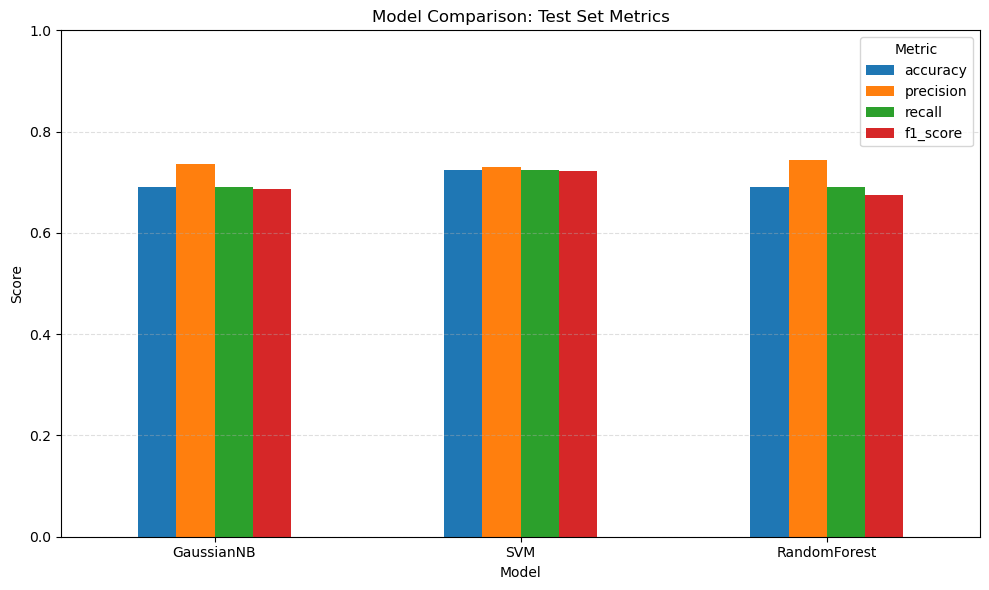

C:\Users\Minh Tran\AppData\Local\Temp\ipykernel_25192\836665475.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


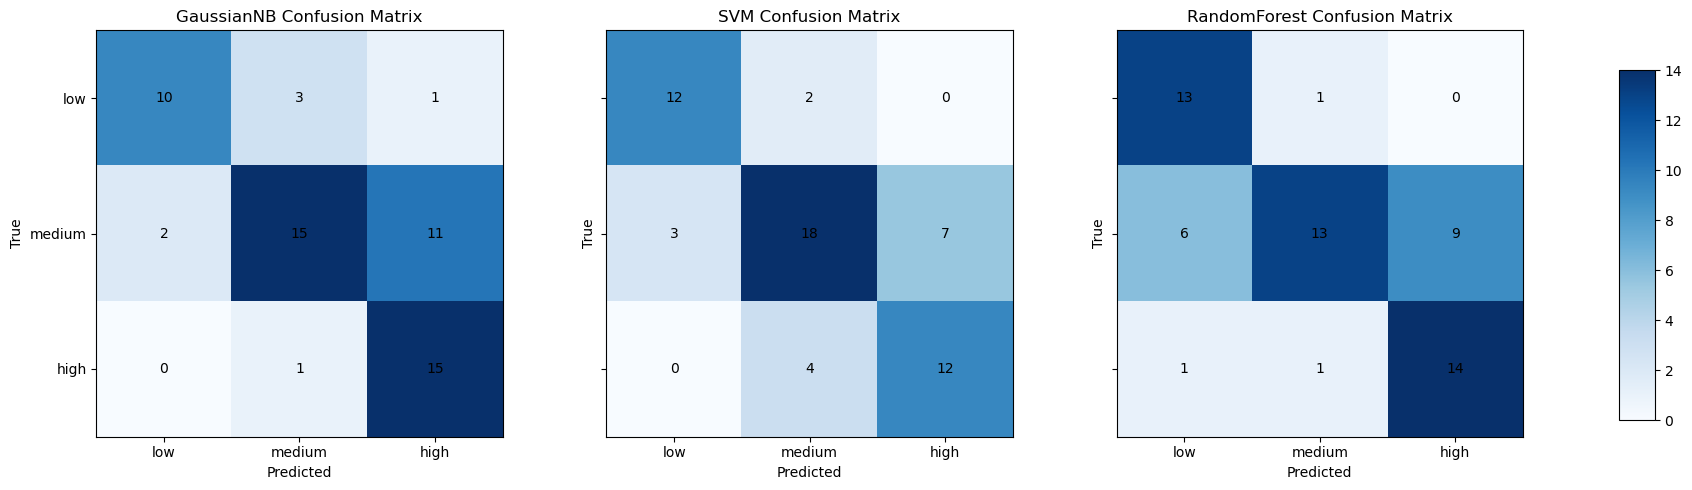

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Compute metrics
model_names = ['GaussianNB', 'SVM', 'RandomForest']
metrics = {}

for name, y_pred in zip(model_names, [y_pred_gnb, y_pred_svm, y_pred_rf]):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    accuracy = accuracy_score(y_test, y_pred)
    metrics[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

compare_df = pd.DataFrame(metrics).T
compare_df# Bar chart for accuracy / precision / recall / f1
ax = compare_df.plot.bar(
    figsize=(10, 6),
    rot=0,
    ylim=(0, 1),
    title='Model Comparison: Test Set Metrics'
)
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()# Confusion matrix heatmaps
labels = ['low', 'medium', 'high']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, name, y_pred in zip(axes, model_names, [y_pred_gnb, y_pred_svm, y_pred_rf]):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

# --- Create a dedicated axis for the colorbar on the right ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax)
plt.tight_layout(rect=[0, 0, 0.9, 1])  
plt.show()